# Phase 1 — Bayesian Causal Tracing: Faithful vs Hallucinated

**Goal**: Test whether hallucinated factual recall shows higher causal ambiguity (posterior entropy H) than faithful recall.

**Method**: Activation patching via `apply_steering` on 100 factual prompts, Bayesian inference over K=6 layer-group mechanisms.

In [1]:
import os, sys, time, re
import numpy as np
from scipy import stats
from scipy.special import logsumexp
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['DejaVu Sans']
import warnings; warnings.filterwarnings("ignore")

os.environ['GGML_CUDA_DISABLE_GRAPHS'] = '1'
os.makedirs('/workspace/Data/bayesian_phase1', exist_ok=True)

import neuroscope

def softmax(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()

def strip_think(text):
    return re.sub(r"<think>.*?</think>\s*", "", text, flags=re.DOTALL)

def check_match(generated, expected_list):
    gen = generated.lower().strip()
    for exp in expected_list:
        if len(exp) <= 2:
            if re.search(r'(?<![a-zA-Z0-9])' + re.escape(exp.lower()) + r'(?![a-zA-Z0-9])', gen):
                return True
        else:
            if exp.lower() in gen:
                return True
    return False

MODEL = "/workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf"
engine = neuroscope.Engine(MODEL, n_ctx=2048, n_gpu_layers=99)
n_layers = engine.model_info.n_layers
n_embd = engine.model_info.n_embd
print(f"Model: {engine.model_info.name}")
print(f"Layers: {n_layers}, Dim: {n_embd}, Vocab: {engine.model_info.n_vocab}")

engine.reset()
test_out = engine.generate("The capital of France is", max_tokens=10, temperature=0.01, top_k=1, seed=42)
test_out = strip_think(test_out)
print(f"\nSanity: The capital of France is → {test_out.strip()[:40]}")

ggml_cuda_init: found 1 CUDA devices:
  Device 0: NVIDIA GB10, compute capability 12.1, VMM: yes
ggml_backend_cuda_get_available_uma_memory: final available_memory_kb: 113414204
ggml_backend_cuda_get_available_uma_memory: final available_memory_kb: 113414204
llama_model_load_from_file_impl: using device CUDA0 (NVIDIA GB10) (000f:01:00.0) - 110756 MiB free
llama_model_loader: loaded meta data with 28 key-value pairs and 399 tensors from /workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = qwen3
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                               general.name str              = Qwen3 8B Awq Compatible Instruct
llama_model_loader: - kv   3:                           genera

Model: Qwen3 8B Awq Compatible Instruct
Layers: 36, Dim: 4096, Vocab: 151936

Sanity: The capital of France is → Paris. The capital of the United States 


In [2]:
# ── Factual Recall Dataset ──
# Format: (template_with_{}, subject, [expected_answers], category)
DATASET = [
    # ════════════ World Capitals (30) ════════════
    ("The capital of {} is", "France", ["Paris"], "cap_easy"),
    ("The capital of {} is", "Japan", ["Tokyo"], "cap_easy"),
    ("The capital of {} is", "China", ["Beijing", "Peking"], "cap_easy"),
    ("The capital of {} is", "Germany", ["Berlin"], "cap_easy"),
    ("The capital of {} is", "Italy", ["Rome"], "cap_easy"),
    ("The capital of {} is", "Spain", ["Madrid"], "cap_easy"),
    ("The capital of {} is", "Russia", ["Moscow"], "cap_easy"),
    ("The capital of {} is", "India", ["New Delhi", "Delhi"], "cap_easy"),
    ("The capital of {} is", "Brazil", ["Brasilia"], "cap_easy"),
    ("The capital of {} is", "Canada", ["Ottawa"], "cap_easy"),
    ("The capital of {} is", "Australia", ["Canberra"], "cap_easy"),
    ("The capital of {} is", "Mexico", ["Mexico City"], "cap_easy"),
    ("The capital of {} is", "South Korea", ["Seoul"], "cap_easy"),
    ("The capital of {} is", "Egypt", ["Cairo"], "cap_easy"),
    ("The capital of {} is", "Argentina", ["Buenos Aires"], "cap_easy"),
    ("The capital of {} is", "Thailand", ["Bangkok"], "cap_easy"),
    ("The capital of {} is", "Turkey", ["Ankara"], "cap_easy"),
    ("The capital of {} is", "Sweden", ["Stockholm"], "cap_easy"),
    ("The capital of {} is", "Poland", ["Warsaw"], "cap_easy"),
    ("The capital of {} is", "Indonesia", ["Jakarta"], "cap_easy"),
    ("The capital of {} is", "Myanmar", ["Naypyidaw", "Nay Pyi Taw"], "cap_hard"),
    ("The capital of {} is", "Kazakhstan", ["Astana", "Nur-Sultan"], "cap_hard"),
    ("The capital of {} is", "Tanzania", ["Dodoma"], "cap_hard"),
    ("The capital of {} is", "Ivory Coast", ["Yamoussoukro"], "cap_hard"),
    ("The capital of {} is", "Belize", ["Belmopan"], "cap_hard"),
    ("The capital of {} is", "Burkina Faso", ["Ouagadougou"], "cap_hard"),
    ("The capital of {} is", "Palau", ["Ngerulmud", "Melekeok"], "cap_hard"),
    ("The capital of {} is", "Nauru", ["Yaren"], "cap_hard"),
    ("The capital of {} is", "Micronesia", ["Palikir"], "cap_hard"),
    ("The capital of {} is", "Eswatini", ["Mbabane", "Lobamba"], "cap_hard"),
    # ════════════ Chemical Symbols (20) ════════════
    ("The chemical symbol for {} is", "gold", ["Au"], "chem_easy"),
    ("The chemical symbol for {} is", "silver", ["Ag"], "chem_easy"),
    ("The chemical symbol for {} is", "iron", ["Fe"], "chem_easy"),
    ("The chemical symbol for {} is", "copper", ["Cu"], "chem_easy"),
    ("The chemical symbol for {} is", "sodium", ["Na"], "chem_easy"),
    ("The chemical symbol for {} is", "potassium", ["K"], "chem_easy"),
    ("The chemical symbol for {} is", "mercury", ["Hg"], "chem_easy"),
    ("The chemical symbol for {} is", "lead", ["Pb"], "chem_easy"),
    ("The chemical symbol for {} is", "tin", ["Sn"], "chem_easy"),
    ("The chemical symbol for {} is", "tungsten", ["W"], "chem_easy"),
    ("The chemical symbol for {} is", "antimony", ["Sb"], "chem_hard"),
    ("The chemical symbol for {} is", "strontium", ["Sr"], "chem_hard"),
    ("The chemical symbol for {} is", "molybdenum", ["Mo"], "chem_hard"),
    ("The chemical symbol for {} is", "vanadium", ["V"], "chem_hard"),
    ("The chemical symbol for {} is", "praseodymium", ["Pr"], "chem_hard"),
    ("The chemical symbol for {} is", "ytterbium", ["Yb"], "chem_hard"),
    ("The chemical symbol for {} is", "hafnium", ["Hf"], "chem_hard"),
    ("The chemical symbol for {} is", "rhenium", ["Re"], "chem_hard"),
    ("The chemical symbol for {} is", "thallium", ["Tl"], "chem_hard"),
    ("The chemical symbol for {} is", "gadolinium", ["Gd"], "chem_hard"),
    # ════════════ History (20) ════════════
    ("{} was born in", "Albert Einstein", ["1879"], "hist_easy"),
    ("{} was born in", "Isaac Newton", ["1642", "1643"], "hist_easy"),
    ("{} was born in", "Leonardo da Vinci", ["1452"], "hist_easy"),
    ("{} was born in", "William Shakespeare", ["1564"], "hist_easy"),
    ("{} was born in", "Napoleon Bonaparte", ["1769"], "hist_easy"),
    ("{} began in", "World War I", ["1914"], "hist_easy"),
    ("{} ended in", "World War II", ["1945"], "hist_easy"),
    ("{} was discovered in", "penicillin", ["1928"], "hist_easy"),
    ("{} first landed on the moon in", "Neil Armstrong", ["1969"], "hist_easy"),
    ("{} took place in", "the French Revolution", ["1789"], "hist_easy"),
    ("{} was signed in", "the Magna Carta", ["1215"], "hist_hard"),
    ("{} was completed in", "the Suez Canal", ["1869"], "hist_hard"),
    ("{} was born in", "Confucius", ["551"], "hist_hard"),
    ("{} died in", "Genghis Khan", ["1227"], "hist_hard"),
    ("{} was first performed in", "Beethoven\'s Ninth Symphony", ["1824"], "hist_hard"),
    ("{} was invented in", "the printing press", ["1440", "1450"], "hist_hard"),
    ("{} was founded in", "the Ottoman Empire", ["1299"], "hist_hard"),
    ("{} was built in", "the Colosseum", ["70", "72", "80"], "hist_hard"),
    ("{} was published in", "the Communist Manifesto", ["1848"], "hist_hard"),
    ("{} gained independence in", "Brazil", ["1822"], "hist_hard"),
    # ════════════ Science (15) ════════════
    ("The atomic number of {} is", "hydrogen", ["1"], "sci_easy"),
    ("The atomic number of {} is", "carbon", ["6"], "sci_easy"),
    ("The atomic number of {} is", "oxygen", ["8"], "sci_easy"),
    ("The atomic number of {} is", "iron", ["26"], "sci_easy"),
    ("The atomic number of {} is", "gold", ["79"], "sci_easy"),
    ("The boiling point of {} in degrees Celsius is", "water", ["100"], "sci_easy"),
    ("The freezing point of {} in degrees Celsius is", "water", ["0", "zero"], "sci_easy"),
    ("The number of chromosomes in a {} cell is", "human", ["46"], "sci_easy"),
    ("The atomic number of {} is", "uranium", ["92"], "sci_hard"),
    ("The atomic number of {} is", "plutonium", ["94"], "sci_hard"),
    ("The melting point of {} in degrees Celsius is", "iron", ["1538", "1535", "1536"], "sci_hard"),
    ("The half-life of {} in years is approximately", "carbon-14", ["5730", "5700"], "sci_hard"),
    ("The atomic number of {} is", "berkelium", ["97"], "sci_hard"),
    ("The atomic number of {} is", "lawrencium", ["103"], "sci_hard"),
    ("The atomic number of {} is", "seaborgium", ["106"], "sci_hard"),
    # ════════════ General Knowledge (15) ════════════
    ("The author of {} is", "Romeo and Juliet", ["Shakespeare"], "gen_easy"),
    ("The author of {} is", "Harry Potter", ["Rowling", "J.K."], "gen_easy"),
    ("The inventor of {} is", "the telephone", ["Bell", "Meucci"], "gen_easy"),
    ("The currency of {} is the", "Japan", ["yen"], "gen_easy"),
    ("The currency of {} is the", "United Kingdom", ["pound"], "gen_easy"),
    ("The largest planet in {} is", "the solar system", ["Jupiter"], "gen_easy"),
    ("The longest river in {} is the", "Africa", ["Nile"], "gen_easy"),
    ("The national language of {} is", "Brazil", ["Portuguese"], "gen_easy"),
    ("The author of {} is", "The Brothers Karamazov", ["Dostoevsky", "Dostoyevsky", "Dostoevsk"], "gen_hard"),
    ("The author of {} is", "One Hundred Years of Solitude", ["Marquez", "Garcia"], "gen_hard"),
    ("The composer of {} is", "The Four Seasons", ["Vivaldi"], "gen_hard"),
    ("The currency of {} is the", "Bhutan", ["ngultrum"], "gen_hard"),
    ("The national animal of {} is the", "Scotland", ["unicorn"], "gen_hard"),
    ("The architect of {} is", "the Sagrada Familia", ["Gaudi"], "gen_hard"),
    ("The inventor of {} is", "dynamite", ["Nobel"], "gen_easy"),
]

print(f"Dataset: {len(DATASET)} factual recall prompts")
cats = {}
for _, _, _, c in DATASET:
    cats[c] = cats.get(c, 0) + 1
for c, n in sorted(cats.items()):
    print(f"  {c}: {n}")

CORRUPT_ENTITY = "Zyxwv"

MECHANISMS = {
    'L0-5 Shallow':  list(range(0, 6)),
    'L6-11 Early':   list(range(6, 12)),
    'L12-17 Mid':    list(range(12, 18)),
    'L18-23 Deep':   list(range(18, 24)),
    'L24-29 Late':   list(range(24, 30)),
    'L30-35 Final':  list(range(30, 36)),
}
K = len(MECHANISMS)
MECH_NAMES = list(MECHANISMS.keys())
print(f"\nMechanism hypotheses K = {K}: {MECH_NAMES}")

Dataset: 100 factual recall prompts
  cap_easy: 20
  cap_hard: 10
  chem_easy: 10
  chem_hard: 10
  gen_easy: 9
  gen_hard: 6
  hist_easy: 10
  hist_hard: 10
  sci_easy: 8
  sci_hard: 7

Mechanism hypotheses K = 6: ['L0-5 Shallow', 'L6-11 Early', 'L12-17 Mid', 'L18-23 Deep', 'L24-29 Late', 'L30-35 Final']


In [3]:
print("Phase 1: Generating answers...\n")
gen_results = []
t0 = time.time()

for i, (template, subject, answers, cat) in enumerate(DATASET):
    prompt = template.format(subject)
    engine.reset()
    output = engine.generate(prompt, max_tokens=20, temperature=0.01, top_k=1, seed=42)
    output = strip_think(output)
    if output.startswith(prompt):
        generated = output[len(prompt):]
    else:
        generated = output
    generated = generated.strip()
    is_correct = check_match(generated, answers)
    gen_results.append({
        'idx': i, 'prompt': prompt, 'subject': subject,
        'expected': answers, 'generated': generated[:60],
        'correct': is_correct, 'category': cat
    })
    if (i+1) % 25 == 0:
        print(f"  [{i+1}/{len(DATASET)}] {time.time()-t0:.1f}s")

elapsed = time.time() - t0
faithful_idx = [r['idx'] for r in gen_results if r['correct']]
halluc_idx   = [r['idx'] for r in gen_results if not r['correct']]
is_faithful  = np.array([r['correct'] for r in gen_results])

print(f"\nDone in {elapsed:.1f}s")
print(f"Classification: {len(faithful_idx)} faithful, {len(halluc_idx)} hallucinated")
print(f"\n-- Sample Faithful --")
for r in [g for g in gen_results if g['correct']][:8]:
    print(f"  {r['prompt']} -> {r['generated'][:30]}")
print(f"\n-- Sample Hallucinated --")
for r in [g for g in gen_results if not g['correct']][:8]:
    print(f"  {r['prompt']} -> {r['generated'][:30]}  (expect: {r['expected'][0]})")
print(f"\n-- Per-Category Accuracy --")
cat_stats = {}
for r in gen_results:
    c = r['category']
    if c not in cat_stats: cat_stats[c] = [0, 0]
    cat_stats[c][0] += r['correct']
    cat_stats[c][1] += 1
for c in sorted(cat_stats.keys()):
    cor, tot = cat_stats[c]
    print(f"  {c:>12s}: {cor}/{tot} = {cor/tot:.0%}")

Phase 1: Generating answers...

  [25/100] 16.6s
  [50/100] 33.2s
  [75/100] 49.8s
  [100/100] 66.4s

Done in 66.5s
Classification: 88 faithful, 12 hallucinated

-- Sample Faithful --
  The capital of France is -> Paris. The capital of the Unit
  The capital of Japan is -> Tokyo. The capital of Japan is
  The capital of China is -> Beijing. The capital of the Un
  The capital of Germany is -> Berlin. The capital of France 
  The capital of Italy is -> Rome. The capital of France is
  The capital of Spain is -> Madrid. The capital of France 
  The capital of Russia is -> Moscow. The capital of the Uni
  The capital of India is -> Delhi. The capital of the stat

-- Sample Hallucinated --
  The capital of Brazil is -> Brasília, which is located in   (expect: Brasilia)
  The capital of Turkey is -> a city that is also the capita  (expect: Ankara)
  The capital of Myanmar is -> Yangon, but it was known as Ra  (expect: Naypyidaw)
  The capital of Tanzania is -> Dar es Salaam, which is also t

In [4]:
print("Phase 2: Causal Tracing (activation patching)...\n")

N = len(DATASET)
IE = np.zeros((N, K))
IE_raw = np.zeros((N, K))
IE_full = np.zeros(N)
p_clean_arr = np.zeros(N)
p_corrupt_arr = np.zeros(N)
target_tokens = np.zeros(N, dtype=np.int64)
IE_per_layer = np.zeros((N, n_layers))

t0 = time.time()
for i, (template, subject, answers, cat) in enumerate(DATASET):
    clean_prompt = template.format(subject)
    corrupt_prompt = template.format(CORRUPT_ENTITY)

    # Clean forward
    engine.reset()
    engine.forward(clean_prompt)
    clean_logits = engine.get_logits().copy()
    clean_acts = [a.copy() for a in engine.get_all_activations()]

    # Corrupt forward
    engine.reset()
    engine.forward(corrupt_prompt)
    corrupt_logits = engine.get_logits().copy()
    corrupt_acts = [a.copy() for a in engine.get_all_activations()]

    # Target token & probabilities
    target = int(np.argmax(clean_logits))
    p_clean = float(softmax(clean_logits)[target])
    p_corrupt = float(softmax(corrupt_logits)[target])
    denom = p_clean - p_corrupt

    target_tokens[i] = target
    p_clean_arr[i] = p_clean
    p_corrupt_arr[i] = p_corrupt

    # Per-layer deltas
    deltas = [clean_acts[l] - corrupt_acts[l] for l in range(n_layers)]

    # Per-layer IE
    for l in range(n_layers):
        engine.reset()
        engine.clear_interventions()
        engine.apply_steering(l, deltas[l].astype(np.float32), 1.0)
        engine.forward(corrupt_prompt)
        lgt = engine.get_logits()
        p_l = float(softmax(lgt)[target])
        IE_per_layer[i, l] = (p_l - p_corrupt) / (denom + 1e-10) if abs(denom) > 1e-6 else 0.0
        engine.clear_interventions()

    # Mechanism-group IE (patch all layers in group simultaneously)
    for k, (mech_name, layers) in enumerate(MECHANISMS.items()):
        engine.reset()
        engine.clear_interventions()
        for l in layers:
            engine.apply_steering(l, deltas[l].astype(np.float32), 1.0)
        engine.forward(corrupt_prompt)
        int_logits = engine.get_logits()
        p_int = float(softmax(int_logits)[target])
        ie = (p_int - p_corrupt) / (denom + 1e-10) if abs(denom) > 1e-6 else 0.0
        IE[i, k] = ie
        IE_raw[i, k] = p_int - p_corrupt
        engine.clear_interventions()

    # Full restoration (sanity)
    engine.reset()
    engine.clear_interventions()
    for l in range(n_layers):
        engine.apply_steering(l, deltas[l].astype(np.float32), 1.0)
    engine.forward(corrupt_prompt)
    full_logits = engine.get_logits()
    p_full = float(softmax(full_logits)[target])
    IE_full[i] = (p_full - p_corrupt) / (denom + 1e-10) if abs(denom) > 1e-6 else 0.0
    engine.clear_interventions()

    if (i+1) % 10 == 0:
        elapsed = time.time() - t0
        rate = (i+1) / elapsed
        eta = (N - i - 1) / rate
        print(f"  [{i+1:3d}/{N}] p_clean={p_clean:.3f} p_corrupt={p_corrupt:.3f} "
              f"IE_full={IE_full[i]:.2f} | {elapsed:.0f}s, ~{eta:.0f}s left")

elapsed_total = time.time() - t0
print(f"\nCausal tracing complete: {elapsed_total:.1f}s ({N*(2+K+n_layers+1)} forward passes)")
print(f"\n{'Mechanism':>14s}  {'Mean IE':>8s}  {'Std':>6s}  {'Median':>8s}")
print("-" * 42)
for k, name in enumerate(MECH_NAMES):
    print(f"{name:>14s}  {IE[:, k].mean():8.3f}  {IE[:, k].std():6.3f}  {np.median(IE[:, k]):8.3f}")
print(f"{'FULL':>14s}  {IE_full.mean():8.3f}  {IE_full.std():6.3f}  {np.median(IE_full):8.3f}")

causal_effect = np.abs(p_clean_arr - p_corrupt_arr)
significant = causal_effect > 0.01
print(f"\nSignificant causal effect: {significant.sum()}/{N}")
print(f"Full restoration >50% IE: {(IE_full[significant] > 0.5).mean()*100:.0f}%")

Phase 2: Causal Tracing (activation patching)...

  [ 10/100] p_clean=0.364 p_corrupt=0.000 IE_full=2.75 | 28s, ~250s left
  [ 20/100] p_clean=0.267 p_corrupt=0.000 IE_full=3.71 | 56s, ~222s left
  [ 30/100] p_clean=0.832 p_corrupt=0.006 IE_full=-0.01 | 83s, ~195s left
  [ 40/100] p_clean=0.652 p_corrupt=0.002 IE_full=0.01 | 111s, ~167s left
  [ 50/100] p_clean=0.966 p_corrupt=0.001 IE_full=0.02 | 139s, ~139s left
  [ 60/100] p_clean=0.565 p_corrupt=0.429 IE_full=-3.15 | 166s, ~111s left
  [ 70/100] p_clean=0.938 p_corrupt=0.805 IE_full=-6.07 | 193s, ~83s left
  [ 80/100] p_clean=0.983 p_corrupt=0.920 IE_full=-14.47 | 221s, ~55s left
  [ 90/100] p_clean=0.561 p_corrupt=0.000 IE_full=0.13 | 249s, ~28s left
  [100/100] p_clean=0.314 p_corrupt=0.000 IE_full=0.00 | 277s, ~0s left

Causal tracing complete: 276.6s (4500 forward passes)

     Mechanism   Mean IE     Std    Median
------------------------------------------
  L0-5 Shallow    -1.627   4.627    -0.000
   L6-11 Early     0.569  12

## Bayesian Causal Mechanism Selection

**Likelihood**: P(data | m_k) ~ exp(beta * IE_k)

**Posterior**: P(m_k | D) = exp(beta * IE_k) / sum_k' exp(beta * IE_k')

**Entropy**: H = -sum_k P_k * ln(P_k)

**Test**: H_hallucinated >> H_faithful ?

In [5]:
beta_default = 5.0

def compute_posteriors_and_entropy(IE_matrix, beta):
    N, K = IE_matrix.shape
    posteriors = np.zeros((N, K))
    entropies = np.zeros(N)
    for i in range(N):
        log_liks = beta * IE_matrix[i]
        log_post = log_liks - logsumexp(log_liks)
        post = np.exp(log_post)
        posteriors[i] = post
        entropies[i] = -np.sum(post * np.log(post + 1e-30))
    return posteriors, entropies

posteriors, entropies = compute_posteriors_and_entropy(IE, beta_default)

mask_f = is_faithful & significant
mask_h = (~is_faithful) & significant

H_faithful = entropies[mask_f]
H_halluc   = entropies[mask_h]
H_max = np.log(K)

K_eff_f = np.exp(H_faithful).mean() if len(H_faithful) > 0 else 0
K_eff_h = np.exp(H_halluc).mean() if len(H_halluc) > 0 else 0

print(f"beta = {beta_default}")
print(f"Significant: {mask_f.sum()} faithful, {mask_h.sum()} hallucinated\n")
print(f"{'Group':>14s}  {'Mean H':>8s}  {'Std H':>8s}  {'Median H':>9s}  {'K_eff':>6s}")
print("-" * 52)
if len(H_faithful) > 0:
    print(f"{'Faithful':>14s}  {H_faithful.mean():8.4f}  {H_faithful.std():8.4f}  {np.median(H_faithful):9.4f}  {K_eff_f:6.2f}")
if len(H_halluc) > 0:
    print(f"{'Hallucinated':>14s}  {H_halluc.mean():8.4f}  {H_halluc.std():8.4f}  {np.median(H_halluc):9.4f}  {K_eff_h:6.2f}")
print(f"{'H_max':>14s}  {H_max:8.4f}")

sp = np.sqrt((H_faithful.var(ddof=1) + H_halluc.var(ddof=1)) / 2) if (len(H_faithful)>1 and len(H_halluc)>1) else 1e-10
cohen_d = (H_halluc.mean() - H_faithful.mean()) / sp if sp > 1e-10 else 0
print(f"\nCohen d (H_halluc - H_faithful) = {cohen_d:.3f}")

mean_post_f = posteriors[mask_f].mean(axis=0) if mask_f.sum() > 0 else np.zeros(K)
mean_post_h = posteriors[mask_h].mean(axis=0) if mask_h.sum() > 0 else np.zeros(K)
print(f"\nDominant mechanisms:")
for k, name in enumerate(MECH_NAMES):
    print(f"  {name:>14s}: faithful={mean_post_f[k]:.3f}  halluc={mean_post_h[k]:.3f}")

beta = 5.0
Significant: 86 faithful, 12 hallucinated

         Group    Mean H     Std H   Median H   K_eff
----------------------------------------------------
      Faithful    0.5702    0.5993     0.3584    2.16
  Hallucinated    0.4969    0.4579     0.4100    1.83
         H_max    1.7918

Cohen d (H_halluc - H_faithful) = -0.135

Dominant mechanisms:
    L0-5 Shallow: faithful=0.111  halluc=0.084
     L6-11 Early: faithful=0.097  halluc=0.287
      L12-17 Mid: faithful=0.106  halluc=0.108
     L18-23 Deep: faithful=0.126  halluc=0.034
     L24-29 Late: faithful=0.088  halluc=0.087
    L30-35 Final: faithful=0.472  halluc=0.399


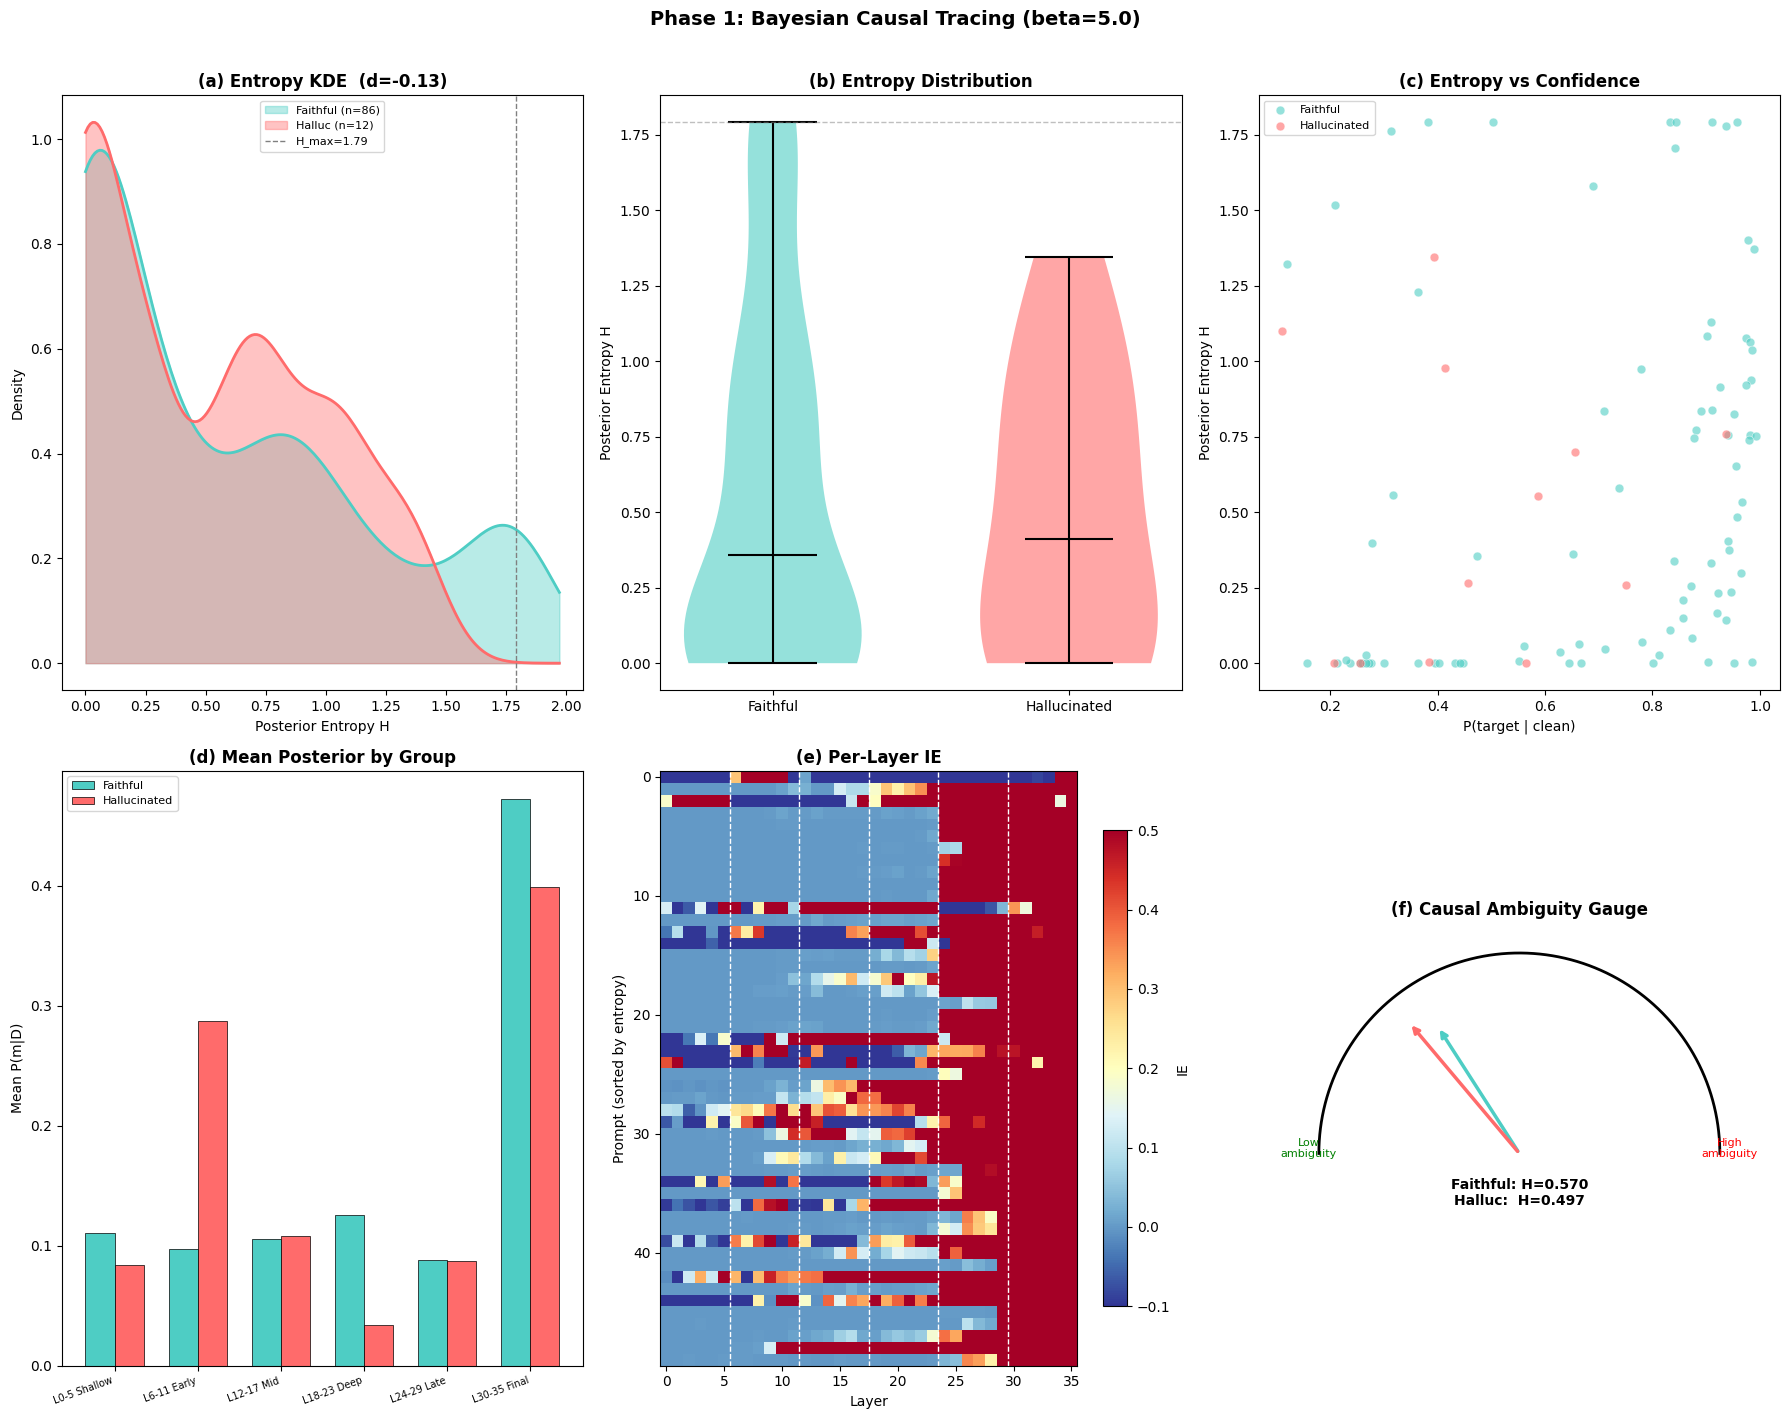

In [6]:
colors_f = '#4ECDC4'
colors_h = '#FF6B6B'
mech_colors = ['#FF6B6B', '#FFE66D', '#4ECDC4', '#95E1D3', '#A8D8EA', '#DDA0DD']

fig = plt.figure(figsize=(18, 14))

# (a) KDE
ax1 = fig.add_subplot(2, 3, 1)
x_range = np.linspace(0, H_max * 1.1, 200)
if len(H_faithful) > 2:
    kde_f = stats.gaussian_kde(H_faithful, bw_method=0.3)
    ax1.fill_between(x_range, kde_f(x_range), alpha=0.4, color=colors_f, label=f'Faithful (n={len(H_faithful)})')
    ax1.plot(x_range, kde_f(x_range), color=colors_f, lw=2)
if len(H_halluc) > 2:
    kde_h = stats.gaussian_kde(H_halluc, bw_method=0.3)
    ax1.fill_between(x_range, kde_h(x_range), alpha=0.4, color=colors_h, label=f'Halluc (n={len(H_halluc)})')
    ax1.plot(x_range, kde_h(x_range), color=colors_h, lw=2)
ax1.axvline(H_max, color='grey', ls='--', lw=1, label=f'H_max={H_max:.2f}')
ax1.set_xlabel('Posterior Entropy H')
ax1.set_ylabel('Density')
ax1.set_title(f'(a) Entropy KDE  (d={cohen_d:.2f})', fontweight='bold')
ax1.legend(fontsize=8)

# (b) Violin
ax2 = fig.add_subplot(2, 3, 2)
data_box = [H_faithful, H_halluc]
if len(H_faithful) > 1 and len(H_halluc) > 1:
    parts = ax2.violinplot(data_box, positions=[0, 1], showmedians=True, widths=0.6)
    for idx_v, pc in enumerate(parts['bodies']):
        pc.set_facecolor([colors_f, colors_h][idx_v])
        pc.set_alpha(0.6)
    for key in ['cmins', 'cmaxes', 'cmedians', 'cbars']:
        parts[key].set_color('black')
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Faithful', 'Hallucinated'])
ax2.set_ylabel('Posterior Entropy H')
ax2.set_title('(b) Entropy Distribution', fontweight='bold')
ax2.axhline(H_max, color='grey', ls='--', lw=1, alpha=0.5)

# (c) Scatter: H vs p_clean
ax3 = fig.add_subplot(2, 3, 3)
ax3.scatter(p_clean_arr[mask_f], entropies[mask_f], c=colors_f, alpha=0.6, s=40, label='Faithful', edgecolors='white', lw=0.5)
ax3.scatter(p_clean_arr[mask_h], entropies[mask_h], c=colors_h, alpha=0.6, s=40, label='Hallucinated', edgecolors='white', lw=0.5)
ax3.set_xlabel('P(target | clean)')
ax3.set_ylabel('Posterior Entropy H')
ax3.set_title('(c) Entropy vs Confidence', fontweight='bold')
ax3.legend(fontsize=8)

# (d) Mean Posterior per Group
ax4 = fig.add_subplot(2, 3, 4)
x = np.arange(K)
w = 0.35
ax4.bar(x - w/2, mean_post_f, w, color=colors_f, edgecolor='black', lw=0.5, label='Faithful')
ax4.bar(x + w/2, mean_post_h, w, color=colors_h, edgecolor='black', lw=0.5, label='Hallucinated')
ax4.set_xticks(x)
ax4.set_xticklabels(MECH_NAMES, fontsize=7, rotation=20, ha='right')
ax4.set_ylabel('Mean P(m|D)')
ax4.set_title('(d) Mean Posterior by Group', fontweight='bold')
ax4.legend(fontsize=8)

# (e) IE Heatmap
ax5 = fig.add_subplot(2, 3, 5)
sig_idx = np.where(significant)[0]
if len(sig_idx) > 0:
    order = sig_idx[np.argsort(entropies[sig_idx])]
    n_show = min(50, len(order))
    ie_show = IE_per_layer[order[:n_show]]
    im = ax5.imshow(ie_show, aspect='auto', cmap='RdYlBu_r', vmin=-0.1, vmax=0.5)
    ax5.set_xlabel('Layer')
    ax5.set_ylabel('Prompt (sorted by entropy)')
    ax5.set_title('(e) Per-Layer IE', fontweight='bold')
    plt.colorbar(im, ax=ax5, shrink=0.8, label='IE')
    for boundary in [6, 12, 18, 24, 30]:
        ax5.axvline(boundary - 0.5, color='white', lw=1, ls='--')

# (f) Gauge
ax6 = fig.add_subplot(2, 3, 6)
H_mean_f = H_faithful.mean() if len(H_faithful) > 0 else 0
H_mean_h = H_halluc.mean() if len(H_halluc) > 0 else 0
theta = np.linspace(np.pi, 0, 200)
ax6.plot(np.cos(theta), np.sin(theta), 'k-', lw=2)
frac_f = H_mean_f / H_max if H_max > 0 else 0
angle_f = np.pi * (1 - frac_f)
ax6.annotate('', xy=(0.75*np.cos(angle_f), 0.75*np.sin(angle_f)), xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color=colors_f, lw=2.5))
frac_h = H_mean_h / H_max if H_max > 0 else 0
angle_h = np.pi * (1 - frac_h)
ax6.annotate('', xy=(0.85*np.cos(angle_h), 0.85*np.sin(angle_h)), xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color=colors_h, lw=2.5))
ax6.text(0, -0.12, f'Faithful: H={H_mean_f:.3f}\nHalluc:  H={H_mean_h:.3f}',
         ha='center', va='top', fontsize=10, fontweight='bold')
ax6.text(-1.05, -0.02, 'Low\nambiguity', ha='center', fontsize=8, color='green')
ax6.text(1.05, -0.02, 'High\nambiguity', ha='center', fontsize=8, color='red')
ax6.set_xlim(-1.3, 1.3); ax6.set_ylim(-0.3, 1.15)
ax6.set_aspect('equal'); ax6.axis('off')
ax6.set_title('(f) Causal Ambiguity Gauge', fontweight='bold')

fig.suptitle(f'Phase 1: Bayesian Causal Tracing (beta={beta_default})', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/workspace/Data/bayesian_phase1/main_results.png', dpi=150, bbox_inches='tight')
plt.show()

STATISTICAL TESTS

Mann-Whitney U (H_halluc > H_faithful):
  U = 488.0, p = 0.621290  n.s.

Kolmogorov-Smirnov:
  D = 0.1512, p = 0.937073

Welch t-test:
  t = -0.480, p = 0.637387

AUC (entropy as hallucination predictor): 0.473

BETA SENSITIVITY


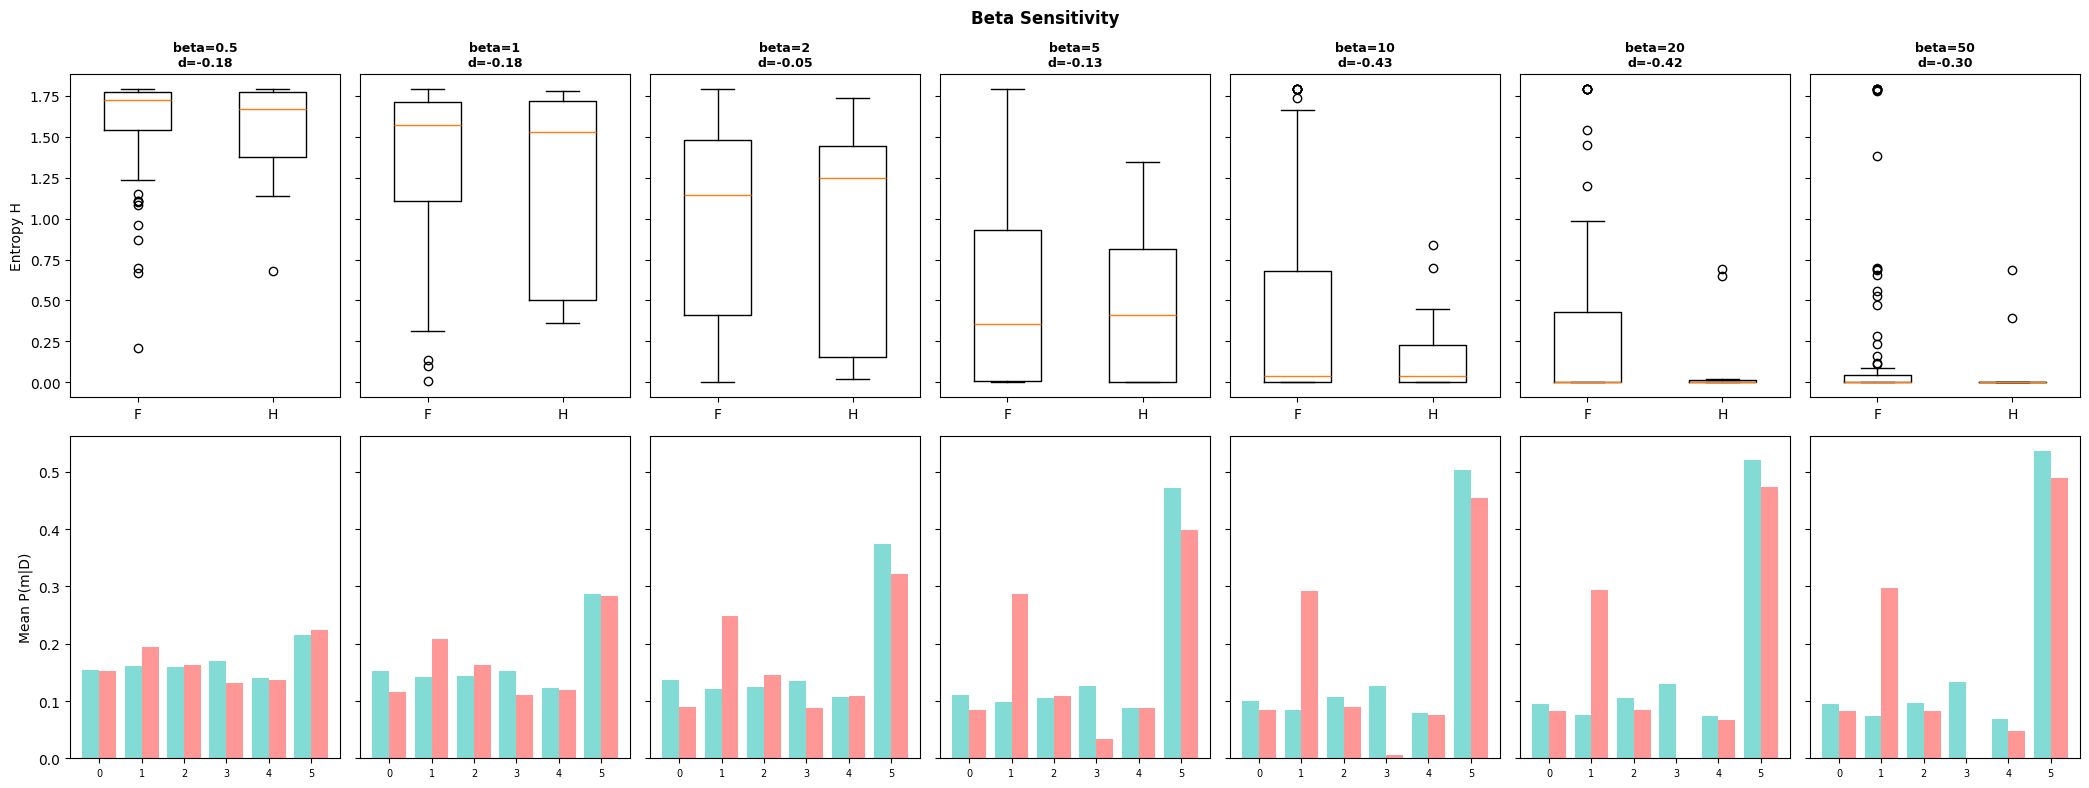


 beta   Cohen d     p-value   H_faith   H_halluc
----------------------------------------------
  0.5    -0.182    0.673558    1.5875     1.5287  n.s.
  1.0    -0.183    0.613019    1.3467     1.2472  n.s.
  2.0    -0.048    0.510808    1.0048     0.9739  n.s.
  5.0    -0.135    0.621290    0.5702     0.4969  n.s.
 10.0    -0.428    0.729838    0.3930     0.1969  n.s.
 20.0    -0.423    0.750908    0.2916     0.1141  n.s.
 50.0    -0.302    0.740484    0.2042     0.0896  n.s.


In [7]:
print("=" * 60)
print("STATISTICAL TESTS")
print("=" * 60)

if len(H_faithful) > 1 and len(H_halluc) > 1:
    U, p_mw = stats.mannwhitneyu(H_halluc, H_faithful, alternative='greater')
    print(f"\nMann-Whitney U (H_halluc > H_faithful):")
    sig = '***' if p_mw<0.001 else '**' if p_mw<0.01 else '*' if p_mw<0.05 else 'n.s.'
    print(f"  U = {U:.1f}, p = {p_mw:.6f}  {sig}")

    ks_stat, p_ks = stats.ks_2samp(H_faithful, H_halluc)
    print(f"\nKolmogorov-Smirnov:")
    print(f"  D = {ks_stat:.4f}, p = {p_ks:.6f}")

    t_stat, p_t = stats.ttest_ind(H_halluc, H_faithful, equal_var=False)
    print(f"\nWelch t-test:")
    print(f"  t = {t_stat:.3f}, p = {p_t:.6f}")

    from sklearn.metrics import roc_auc_score
    y_true = np.concatenate([np.zeros(mask_f.sum()), np.ones(mask_h.sum())])
    y_score = np.concatenate([entropies[mask_f], entropies[mask_h]])
    auc_h = roc_auc_score(y_true, y_score) if len(np.unique(y_true)) == 2 else 0.5
    print(f"\nAUC (entropy as hallucination predictor): {auc_h:.3f}")
else:
    p_mw = p_ks = p_t = 1.0
    auc_h = 0.5
    print("Insufficient samples for statistical tests")

# beta sensitivity
print(f"\n{'=' * 60}")
print("BETA SENSITIVITY")
print(f"{'=' * 60}")

beta_values = [0.5, 1, 2, 5, 10, 20, 50]
fig, axes = plt.subplots(2, len(beta_values), figsize=(3*len(beta_values), 8), sharey='row')
sens_results = []

for bi, beta_val in enumerate(beta_values):
    post_b, ent_b = compute_posteriors_and_entropy(IE, beta_val)
    Hf = ent_b[mask_f]
    Hh = ent_b[mask_h]
    sp_b = np.sqrt((Hf.var(ddof=1) + Hh.var(ddof=1)) / 2) if (len(Hf)>1 and len(Hh)>1) else 1e-10
    d_b = (Hh.mean() - Hf.mean()) / sp_b if sp_b > 1e-10 else 0
    _, p_b = stats.mannwhitneyu(Hh, Hf, alternative='greater') if (len(Hf)>1 and len(Hh)>1) else (0, 1)
    sens_results.append((beta_val, d_b, p_b, Hf.mean(), Hh.mean()))

    ax = axes[0, bi]
    if len(Hf) > 0 and len(Hh) > 0:
        ax.boxplot([Hf, Hh], labels=['F', 'H'], widths=0.5)
    ax.set_title(f'beta={beta_val}\nd={d_b:.2f}', fontsize=9, fontweight='bold')
    if bi == 0: ax.set_ylabel('Entropy H')

    ax2 = axes[1, bi]
    mf = post_b[mask_f].mean(axis=0) if mask_f.sum() > 0 else np.zeros(K)
    mh = post_b[mask_h].mean(axis=0) if mask_h.sum() > 0 else np.zeros(K)
    x = np.arange(K)
    ax2.bar(x - 0.2, mf, 0.4, color=colors_f, alpha=0.7)
    ax2.bar(x + 0.2, mh, 0.4, color=colors_h, alpha=0.7)
    ax2.set_xticks(x)
    ax2.set_xticklabels([str(i) for i in range(K)], fontsize=7)
    if bi == 0: ax2.set_ylabel('Mean P(m|D)')

fig.suptitle('Beta Sensitivity', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/workspace/Data/bayesian_phase1/beta_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'beta':>5s}  {'Cohen d':>8s}  {'p-value':>10s}  {'H_faith':>8s}  {'H_halluc':>9s}")
print("-" * 46)
for beta_val, d_b, p_b, hf, hh in sens_results:
    sig = '***' if p_b < 0.001 else '**' if p_b < 0.01 else '*' if p_b < 0.05 else 'n.s.'
    print(f"{beta_val:5.1f}  {d_b:8.3f}  {p_b:10.6f}  {hf:8.4f}  {hh:9.4f}  {sig}")

In [8]:
np.savez('/workspace/Data/bayesian_phase1/phase1_results.npz',
    is_faithful=is_faithful,
    significant=significant,
    p_clean=p_clean_arr,
    p_corrupt=p_corrupt_arr,
    target_tokens=target_tokens,
    IE=IE, IE_raw=IE_raw, IE_full=IE_full,
    IE_per_layer=IE_per_layer,
    posteriors=posteriors,
    entropies=entropies,
    beta_default=beta_default,
    n_prompts=N, n_mechanisms=K,
    mechanism_names=np.array(MECH_NAMES),
)

print("=" * 60)
print("PHASE 1 FINAL RESULTS")
print("=" * 60)
print(f"\nDataset: {N} prompts | Faithful: {mask_f.sum()} | Hallucinated: {mask_h.sum()}")
print(f"\nBayesian Entropy (beta={beta_default}):")
if len(H_faithful) > 0:
    print(f"  Faithful:     H = {H_faithful.mean():.4f} +/- {H_faithful.std():.4f}")
if len(H_halluc) > 0:
    print(f"  Hallucinated: H = {H_halluc.mean():.4f} +/- {H_halluc.std():.4f}")
print(f"  Cohen d = {cohen_d:.3f}")

if cohen_d > 0.5:
    verdict = "STRONG support for H1: hallucination = causal ambiguity"
elif cohen_d > 0.2:
    verdict = "MODERATE support for H1"
elif cohen_d > 0:
    verdict = "WEAK support for H1"
else:
    verdict = "H1 NOT supported"
print(f"\nVerdict: {verdict}")
print(f"\nSaved to /workspace/Data/bayesian_phase1/phase1_results.npz")

PHASE 1 FINAL RESULTS

Dataset: 100 prompts | Faithful: 86 | Hallucinated: 12

Bayesian Entropy (beta=5.0):
  Faithful:     H = 0.5702 +/- 0.5993
  Hallucinated: H = 0.4969 +/- 0.4579
  Cohen d = -0.135

Verdict: H1 NOT supported

Saved to /workspace/Data/bayesian_phase1/phase1_results.npz
